# Módulo 12 · Prophet: fundamentos + pasajeros de avión

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/02-prophet-fundamentos-pasajeros-avion`. Se usa el dataset clásico `AirPassengers` (pasajeros mensuales de aerolíneas internacionales, 1949-1960, el mismo que Box y Jenkins usaron para popularizar el análisis de series temporales) para introducir **Prophet**, la librería de Meta pensada para series con tendencia y estacionalidad fuerte.

In [1]:
# Prophet vive ahora en el paquete `prophet` (fbprophet quedó descontinuado).
# La primera vez que se usa en una máquina, cmdstanpy necesita compilar CmdStan:
import cmdstanpy
cmdstanpy.install_cmdstan()  # ya cacheado tras la primera ejecución: ~5-10 min solo la primera vez

CmdStan install directory: /Users/juangabriel/.cmdstan
CmdStan version 2.40.0 already installed
Test model compilation


True

## Carga del dataset

`AirPassengers` no depende de ninguna descarga en vivo: es una serie cerrada y ya perfectamente conocida, exportada aquí desde R (`datasets::AirPassengers`) a CSV. Prophet exige columnas llamadas exactamente `ds` (fecha) e `y` (valor).

In [2]:
import pandas as pd

df = pd.read_csv("airline_passengers.csv")
df["ds"] = pd.to_datetime(df["month"], format="%Y-%m")
df["y"] = df["passengers"]
df = df[["ds", "y"]]
print(df.shape)
df.head()

(144, 2)


,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


## Ajuste del modelo

A diferencia de ARIMA o SARIMAX, Prophet no exige elegir `(p,d,q)` ni diferenciar a mano: modela la serie como tendencia + estacionalidad + festivos (opcional) directamente sobre la escala original.

In [3]:
from prophet import Prophet

m = Prophet(seasonality_mode="multiplicative")  # multiplicativa: la amplitud estacional crece con el nivel
m.fit(df)

Importing plotly failed. Interactive plots will not work.


18:54:31 - cmdstanpy - INFO - Chain [1] start processing


18:54:33 - cmdstanpy - INFO - Chain [1] done processing


## Predicción a 24 meses vista

In [4]:
future = m.make_future_dataframe(periods=24, freq="MS")
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

,ds,yhat,yhat_lower,yhat_upper
162,1962-07-01,709.080772,694.451060,723.691728
163,1962-08-01,707.903203,693.508026,722.800892
164,1962-09-01,600.402654,586.017443,614.888892
165,1962-10-01,526.038881,512.127720,540.164250
166,1962-11-01,458.044346,443.628601,472.703020
167,1962-12-01,511.878778,497.370752,527.093955


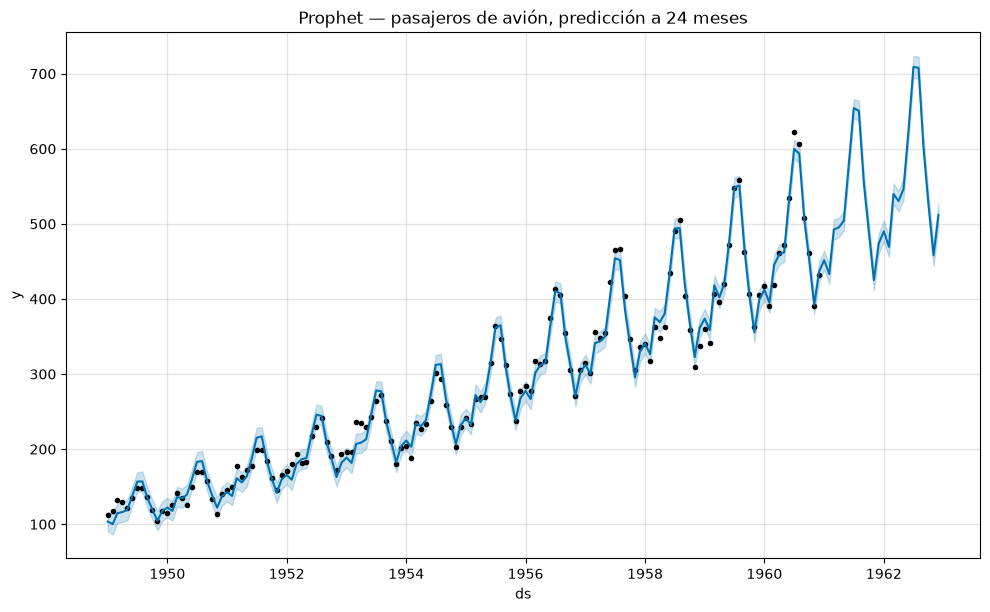

In [5]:
import matplotlib.pyplot as plt

fig1 = m.plot(forecast)
plt.title("Prophet — pasajeros de avión, predicción a 24 meses")
plt.savefig("prophet_forecast.png", dpi=110, bbox_inches="tight")
plt.show()

## Descomposición en componentes

La ventaja pedagógica de Prophet: separa automáticamente la serie en tendencia y estacionalidad anual, cada una inspeccionable por separado — no hace falta un STL manual aparte, aunque el resultado es conceptualmente el mismo que se vio en el Módulo 3.

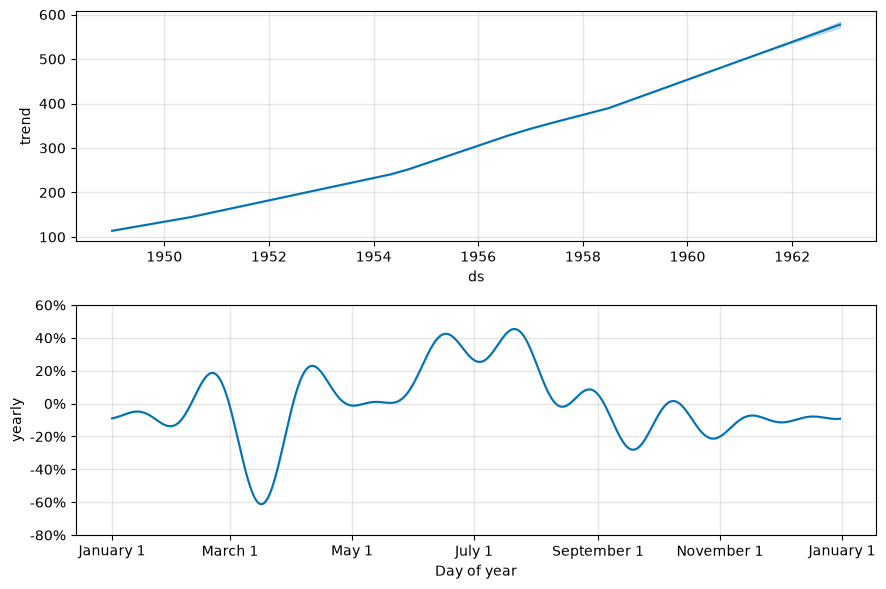

In [6]:
fig2 = m.plot_components(forecast)
plt.savefig("prophet_components.png", dpi=110, bbox_inches="tight")
plt.show()

## Cierre

Prophet ajustó tendencia y estacionalidad multiplicativa sin diferenciar la serie a mano ni elegir un orden `(p,d,q)`. Esa comodidad tiene un coste que se cuantifica más adelante en el módulo, en la lección de comparación Auto ARIMA vs. Prophet: cuál de los dos predice mejor, en términos de error real (RMSE), sobre el mismo dataset.